# Real-world DEM workflow — Mount Hood, Oregon (SRTM 1° tile)

This notebook downloads a **real 30 m SRTM tile from AWS Open Data** (no auth required) and
exercises the full digital-rivers stack on it: hydro pipeline, watershed delineation, terrain
attributes, hydrologic indices, and HAND.

* **Source:** Mapzen Terrain Tiles via AWS Open Data
  (`s3://elevation-tiles-prod/skadi/N45/N45W122.hgt.gz`) — SRTM v3 data from NASA, public
  domain.
* **Area:** 1° × 1° tile covering ~45–46°N, 121–122°W — includes Mount Hood (3 429 m),
  the Sandy / Salmon / Hood / White River drainages, and a slice of the Cascade Range.
* **Resolution:** ~30 m × 30 m (3 601 × 3 601 cells in the full tile).
* **License:** Public domain (NASA SRTM data; AWS Open Data redistribution).

We crop to a ~25 × 25 km window around Mount Hood for fast execution (~800 × 800 cells).
The full tile is too slow for the O(N · search_radius) horizon-walk kernels at full resolution
in a notebook context.

In [1]:
import matplotlib.pyplot as plt
# Lower the inline-figure DPI to keep the executed notebook under ~5 MB.
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80

## 1. Download + cache the SRTM tile

In [2]:
import gzip
import os
import urllib.request
from pathlib import Path

def _resolve_data_dir() -> Path:
    # Walk up from cwd until we find the project root (marked by
    # pyproject.toml). Cache lives at <project>/examples/data/.
    cwd = Path.cwd().resolve()
    for parent in (cwd, *cwd.parents):
        if (parent / "pyproject.toml").exists():
            d = parent / "examples" / "data"
            d.mkdir(parents=True, exist_ok=True)
            return d
    d = cwd / "data"
    d.mkdir(exist_ok=True)
    return d
DATA_DIR = _resolve_data_dir()
DATA_DIR.mkdir(parents=True, exist_ok=True)
HGT_GZ = DATA_DIR / "N45W122.hgt.gz"
HGT = DATA_DIR / "N45W122.hgt"
SRC_URL = "https://elevation-tiles-prod.s3.amazonaws.com/skadi/N45/N45W122.hgt.gz"

if not HGT.exists():
    if not HGT_GZ.exists():
        print(f"Downloading {SRC_URL} ...")
        urllib.request.urlretrieve(SRC_URL, HGT_GZ)
    print(f"Decompressing {HGT_GZ.name} ...")
    with gzip.open(HGT_GZ, "rb") as src, open(HGT, "wb") as dst:
        dst.write(src.read())

print(f"HGT file size: {HGT.stat().st_size / 1024 / 1024:.1f} MB")

HGT file size: 24.7 MB


## 2. Load the SRTM tile and crop to the Mount Hood area

SRTM HGT format = headerless big-endian int16 grid. The N45W122 tile covers
45.0°–46.0° N, 122.0°–121.0° W with 3601 × 3601 cells (1 arc-second ≈ 30 m at this
latitude).

Mount Hood summit is at approximately 45.374°N, 121.696°W. We crop to a 0.25°-wide
window around it.

In [3]:
import numpy as np

# Read raw SRTM HGT — big-endian int16, 3601 × 3601 grid, no header.
raw = np.fromfile(HGT, dtype=">i2").reshape(3601, 3601)
print(f"Full SRTM tile: shape={raw.shape}  range=[{raw.min()}, {raw.max()}] m")

# Tile origin is the NW corner of the 1° cell.
tile_lat_n, tile_lon_w = 46.0, -122.0
step_deg = 1.0 / 3600.0  # 1 arc-second

# Mount Hood crop window — 0.25° square centred on the summit.
summit_lat, summit_lon = 45.374, -121.696
half_w_deg = 0.125
lat_top = summit_lat + half_w_deg
lat_bot = summit_lat - half_w_deg
lon_left = summit_lon - half_w_deg
lon_right = summit_lon + half_w_deg
row_top = int(round((tile_lat_n - lat_top) / step_deg))
row_bot = int(round((tile_lat_n - lat_bot) / step_deg))
col_left = int(round((lon_left - tile_lon_w) / step_deg))
col_right = int(round((lon_right - tile_lon_w) / step_deg))
subset = raw[row_top:row_bot, col_left:col_right].astype(np.float32)
# SRTM uses -32768 as no-data — convert to NaN-friendly sentinel.
subset = np.where(subset <= -1000, -9999.0, subset)
print(f"Mount Hood crop: shape={subset.shape}  "
      f"range=[{subset[subset != -9999.0].min():.0f}, "
      f"{subset[subset != -9999.0].max():.0f}] m")

Full SRTM tile: shape=(3601, 3601)  range=[3, 3422] m
Mount Hood crop: shape=(900, 900)  range=[568, 3422] m


## 3. Wrap as a `Dataset` in a metric CRS

SRTM is in geographic coordinates (degrees). Hydrology operations want metric units so cell-size
ratios make sense. We approximate by treating each cell as a uniform metric square at the
Mount Hood latitude (45.37°): cell ≈ 30 m × 30 m. For a polished workflow we'd reproject; this
approximation is fine for demonstration.

In [4]:
from pyramids.dataset import Dataset
from digitalrivers import DEM

cell_size_m = 30.0
ds = Dataset.create_from_array(
    subset, top_left_corner=(0.0, 0.0), cell_size=cell_size_m,
    epsg=32610, no_data_value=-9999.0,  # UTM 10N (approximate)
)
dem = DEM(ds.raster)
valid = subset[subset != -9999.0]
print(f"Mount Hood DEM    : {dem.values.shape}  "
      f"elev range [{valid.min():.0f}, {valid.max():.0f}] m")

2026-06-09 23:05:38 | INFO | pyramids.base.config | Logging is configured.


Mount Hood DEM    : (900, 900)  elev range [568, 3422] m


## Visualise: hillshade + elevation colormap

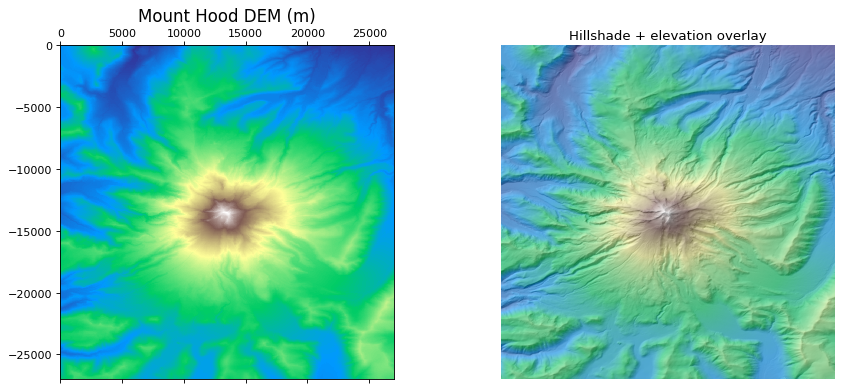

In [5]:
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 0: elevation colormap via pyramids Dataset.plot.
dem.plot(band=0, ax=axes[0], exclude_value=dem.no_data_value[0],
         cmap="terrain", title="Mount Hood DEM (m)", add_colorbar=False)

# Panel 1: pyramids hillshade as the base, then a translucent elevation overlay.
# The alpha-blended overlay is kept in matplotlib (Dataset.plot has no alpha).
shade = np.asarray(dem.hillshade(azimuth=315.0, altitude=45.0), dtype=np.float32)
elev = dem.values
elev_for_plot = np.where(elev == dem.no_data_value[0], np.nan, elev)
axes[1].imshow(shade, cmap="gray", origin="upper")
axes[1].imshow(elev_for_plot, cmap="terrain", origin="upper", alpha=0.55)
axes[1].set_title("Hillshade + elevation overlay")
axes[1].axis("off")
fig.tight_layout()
plt.show()


## 4. Hydrology pipeline — composite

Single-call fill → flow_direction → accumulate → streams.

In [6]:
bundle = dem.full_hydro_pipeline(
    fill_method="priority_flood",
    flow_method="d8",
    stream_threshold_cells=200,  # ~18 ha minimum upstream area
)
filled = bundle["filled_dem"]
fd = bundle["flow_direction"]
acc = bundle["accumulation"]
streams = bundle["streams"]

sm = streams.read_array().astype(bool)
print(f"Stream cells       : {int(sm.sum()):>8d}")
print(f"Accumulation max   : {int(acc.read_array().max()):>8d} cells")
print(f"Largest catchment  : {int(acc.read_array().max()) * cell_size_m * cell_size_m / 1e6:.2f} km²")

Stream cells       :    20976
Accumulation max   :     5580 cells
Largest catchment  : 5.02 km²


## Visualise: filled DEM, flow direction, accumulation, streams

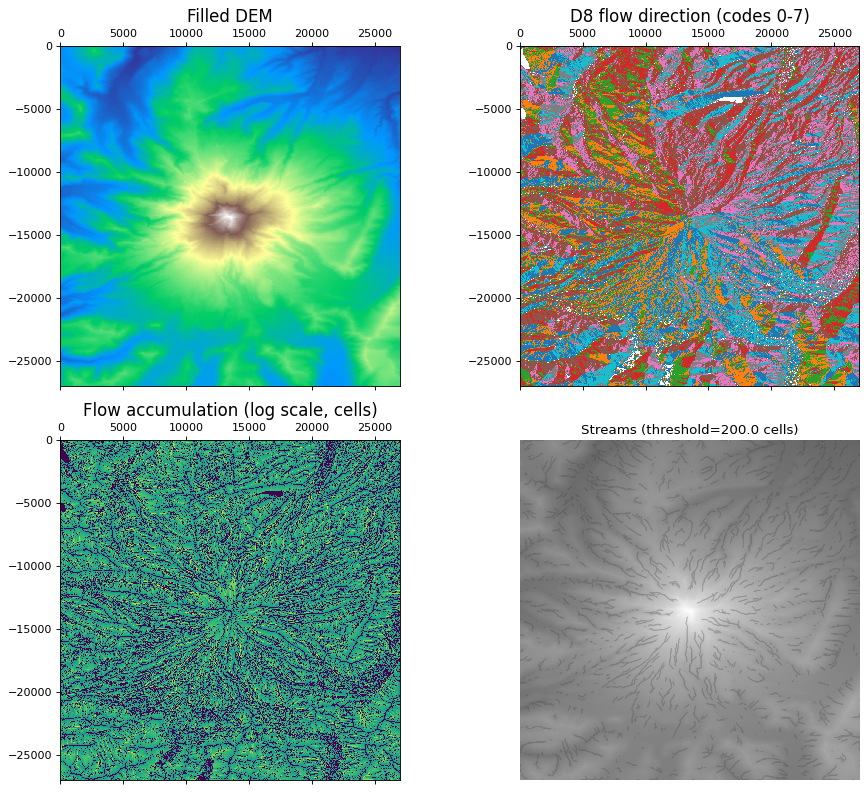

In [7]:
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Filled DEM raster.
filled.plot(band=0, ax=axes[0, 0], exclude_value=filled.no_data_value[0],
            cmap="terrain", title="Filled DEM", add_colorbar=False)

# D8 flow-direction codes (0-7); mask the negative no-data via a dataset_like.
fd_arr = fd.read_array()
fd_show = np.where(fd_arr < 0, np.nan, fd_arr).astype(np.float32)
Dataset.dataset_like(fd, fd_show).plot(
    band=0, ax=axes[0, 1], cmap="tab10",
    title="D8 flow direction (codes 0-7)", add_colorbar=False)

# Flow accumulation on a log-like colour scale.
acc.plot(band=0, ax=axes[1, 0], cmap="viridis", color_scale="sym-lognorm",
         title="Flow accumulation (log scale, cells)", add_colorbar=False)

# Streams overlaid on the grayscale filled DEM (kept matplotlib: raster overlay).
axes[1, 1].imshow(filled.values, cmap="gray", origin="upper", alpha=0.6)
axes[1, 1].imshow(np.where(sm, 1, np.nan), cmap="Blues", origin="upper")
axes[1, 1].set_title("Streams (threshold=" + str(streams.threshold) + " cells)")
axes[1, 1].axis("off")

fig.tight_layout()
plt.show()


## 5. Stream ordering — Strahler + Hack + Topological

* Strahler: topology-based promotion at confluences.
* Hack: main-stem-first; longest path = order 1.
* Topological: sequential Kahn-sort index.

In [8]:
strahler = streams.order(method="strahler", flow_direction=fd).read_array()
hack = streams.order(method="hack", flow_direction=fd).read_array()
topo = streams.order(method="topological", flow_direction=fd).read_array()

print("Strahler orders present:", sorted(set(int(v) for v in strahler[sm])))
print("Hack orders present    :", sorted(set(int(v) for v in hack[sm])))
print(f"Topological index max  : {int(topo.max())} (== stream-cell count {int(sm.sum())})")

Strahler orders present: [0, 1, 2, 3]
Hack orders present    : [1, 2, 3, 4]
Topological index max  : 20976 (== stream-cell count 20976)


## Visualise: Strahler / Hack / Topological orders

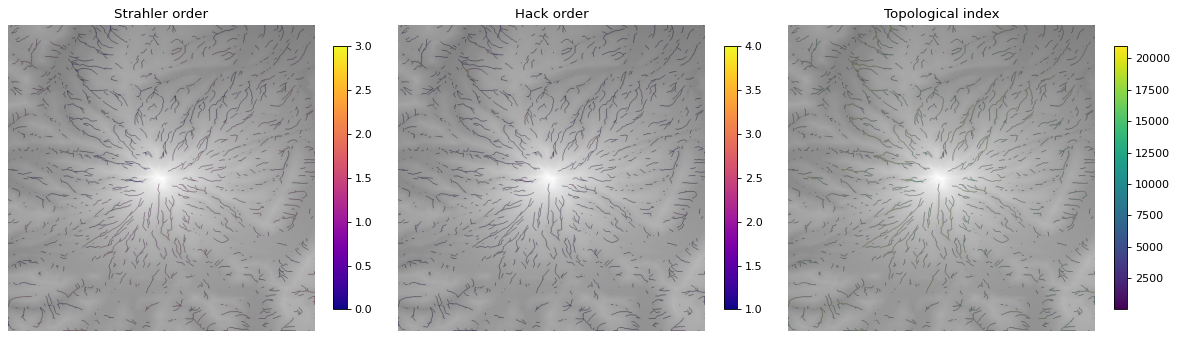

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, arr, title, cmap in zip(
    axes,
    (strahler, hack, topo),
    ("Strahler order", "Hack order", "Topological index"),
    ("plasma", "plasma", "viridis"),
):
    show = np.where(sm, arr.astype(float), np.nan)
    ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
    im = ax.imshow(show, cmap=cmap, origin="upper")
    ax.set_title(title); ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()


## 6. Main stem + vectorisation with sinuosity

Vectorise the stream raster into LineStrings carrying length, drop, slope, and sinuosity per
link. Also flag the cells along the catchment's main stem.

In [10]:
links = streams.to_vector(fd, dem=filled)
main_stem_mask = streams.main_stem(fd)

print(f"Stream links: {len(links)}")
print(f"Longest link:    {links['length_m'].max():>9.0f} m")
print(f"Steepest link:   mean slope {links['mean_slope'].max():.3f} m/m")
print(f"Most sinuous link: sinuosity {links['sinuosity'].max():.2f}")
print(f"Main-stem cells: {int(main_stem_mask.sum())} of {int(sm.sum())}")
print()
print("Top-5 longest links:")
print(links.nlargest(5, 'length_m')[['link_id', 'length_m', 'drop_m', 'mean_slope', 'sinuosity']])

Stream links: 1351
Longest link:         3963 m
Steepest link:   mean slope 0.601 m/m
Most sinuous link: sinuosity 1.64
Main-stem cells: 194 of 20976

Top-5 longest links:
     link_id     length_m  drop_m  mean_slope  sinuosity
648      648  3962.863633   790.0    0.199351   1.133835
817      817  3913.158005   306.0    0.078198   1.140824
760      760  3800.954544  1331.0    0.350175   1.073677
890      890  3403.158005   557.0    0.163672   1.069985
200      200  3068.528137   429.0    0.139806   1.076259


## Visualise: vectorised stream network + main stem overlay

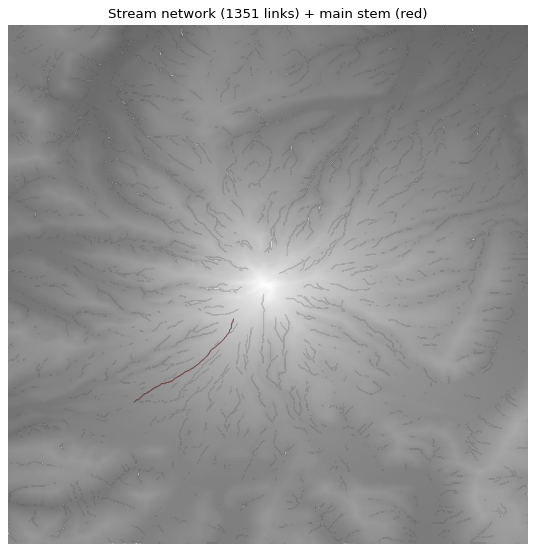

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.6)
ax.imshow(np.where(sm, 1, np.nan), cmap="Blues", origin="upper", alpha=0.7)
ax.imshow(np.where(main_stem_mask, 1, np.nan), cmap="autumn", origin="upper")
ax.set_title("Stream network (" + str(len(links)) + " links) + main stem (red)")
ax.axis("off")
fig.tight_layout()
plt.show()


## 7. Watershed delineation + per-basin statistics

Partition the DEM into terminal-outlet basins, then compute per-basin metrics including the
post-M1 `longest_flow_path_m` column.

In [12]:
basins = fd.basins()
print(f"Basin count: {basins.basin_count}")

stats = basins.statistics(dem=filled, flow_direction=fd, streams=streams)
stats_sorted = stats.sort_values("area_km2", ascending=False).head(10)
print("\nTop 10 basins by area:")
print(stats_sorted[[
    "area_km2", "min_elev", "max_elev", "mean_elev",
    "longest_flow_path_m", "drainage_density_km_per_km2",
]].round(2))

Basin count: 11309



Top 10 basins by area:
          area_km2  min_elev  max_elev  mean_elev  longest_flow_path_m  \
basin_id                                                                 
4281          5.02    1314.0    2859.0    1853.01              5352.27   
1937          4.98     708.0    1499.0    1063.44              5599.19   
2087          4.42     788.0    1369.0    1042.05              3677.06   
11045         4.32    1012.0    1578.0    1225.16              3584.04   
22            3.89     760.0    1347.0    1083.75              3463.16   
6601          3.79    1203.0    3129.0    1913.30              9225.50   
6171          3.78    1530.0    3240.0    2181.61              5922.27   
4328          3.74    1426.0    2716.0    1995.96              5581.98   
4176          3.52     873.0    1556.0    1155.02              3827.06   
768           3.16     602.0    1404.0    1069.51              4860.73   

          drainage_density_km_per_km2  
basin_id                               
4281   

## Visualise: terminal-outlet basins (random colours)

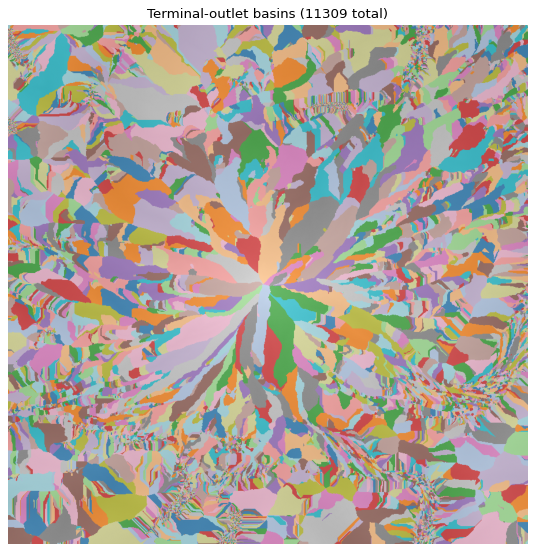

In [13]:
import matplotlib.pyplot as plt

basin_arr = basins.read_array().astype(np.int64)
rng = np.random.default_rng(2026)
n_max = int(basin_arr.max()) + 1
permutation = rng.permutation(n_max).astype(np.float32)
recoloured = np.where(basin_arr > 0, permutation[basin_arr], np.nan)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
ax.imshow(recoloured, cmap="tab20", origin="upper", alpha=0.7)
ax.set_title("Terminal-outlet basins (" + str(basins.basin_count) + " total)")
ax.axis("off")
fig.tight_layout()
plt.show()


## 8. Isobasin equal-area partition

Split the DEM into approximately equal-area sub-basins of ~1 km² each.

In [14]:
iso = fd.isobasins(streams, acc, target_area_km2=1.0)
print(f"Isobasin sub-basins: {iso.basin_count}")

iso_stats = iso.statistics()
print(f"Sub-basin area range: [{iso_stats['area_km2'].min():.3f}, "
      f"{iso_stats['area_km2'].max():.3f}] km²")
print(f"Mean sub-basin area:  {iso_stats['area_km2'].mean():.3f} km² (target 1.0)")

Isobasin sub-basins: 1133


Sub-basin area range: [0.181, 5.023] km²
Mean sub-basin area:  0.330 km² (target 1.0)


## Visualise: equal-area sub-basins

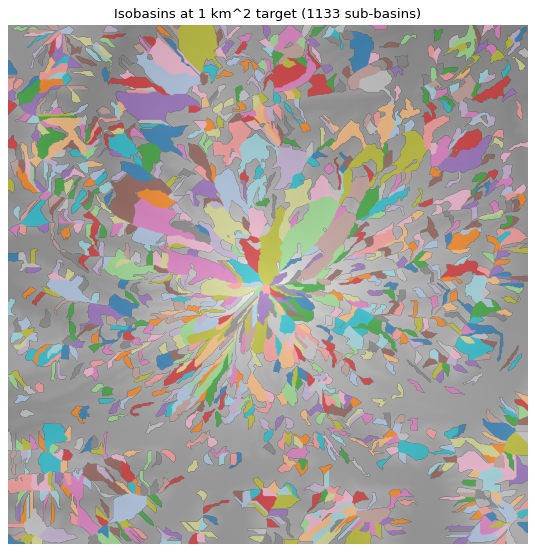

In [15]:
import matplotlib.pyplot as plt

iso_arr = iso.read_array().astype(np.int64)
rng = np.random.default_rng(11)
n_max = int(iso_arr.max()) + 1
permutation = rng.permutation(n_max).astype(np.float32)
recoloured = np.where(iso_arr > 0, permutation[iso_arr], np.nan)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
ax.imshow(recoloured, cmap="tab20", origin="upper", alpha=0.7)
ax.set_title("Isobasins at 1 km^2 target (" + str(iso.basin_count) + " sub-basins)")
ax.axis("off")
fig.tight_layout()
plt.show()


## 9. HAND — D8-traced and Euclidean

Height Above Nearest Drainage — flood-mapping proxy. Two variants on the same DEM.

In [16]:
hand_d8 = filled.hand(streams, fd, method="d8").read_array()
hand_eu = filled.hand(streams, method="euclidean").read_array()

for name, arr in (("D8", hand_d8), ("Euclidean", hand_eu)):
    valid_h = arr[arr != -9999.0]
    print(f"HAND {name:9s}: range=[{valid_h.min():>6.1f}, {valid_h.max():>7.1f}] m  "
          f"mean={valid_h.mean():>6.1f} m")

# Sanity: stream cells must have HAND ≈ 0 in both variants.
assert np.all(np.abs(hand_d8[sm]) < 1e-3) or np.all(np.isnan(hand_d8[sm]) | (hand_d8[sm] == 0))

HAND D8       : range=[   0.0,  1178.0] m  mean=  98.2 m
HAND Euclidean: range=[-268.0,   572.0] m  mean=  46.8 m


## Visualise: HAND D8 vs Euclidean

C:\Users\main\AppData\Local\Temp\ipykernel_31632\3261177650.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


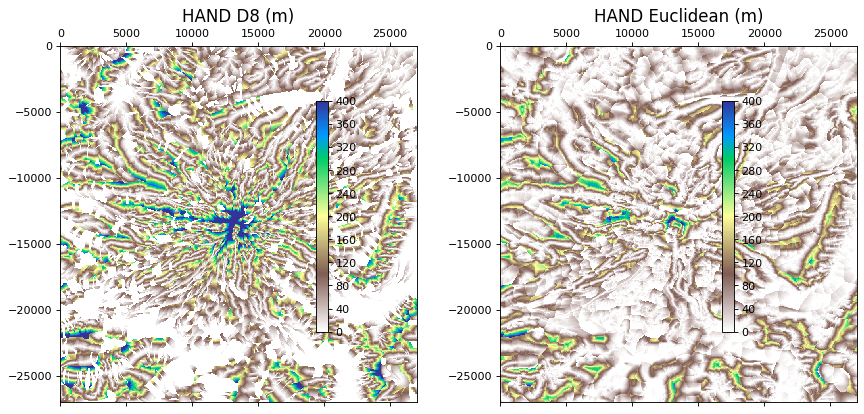

In [17]:
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, arr, title in zip(axes, (hand_d8, hand_eu),
                          ("HAND D8 (m)", "HAND Euclidean (m)")):
    show = np.where(arr == -9999.0, np.nan, arr).astype(np.float32)
    Dataset.dataset_like(filled, show).plot(
        band=0, ax=ax, cmap="terrain_r", vmin=0, vmax=400,
        title=title, add_colorbar=True)
fig.tight_layout()
plt.show()


## 10. Hydrologic indices — TWI / SPI / STI

Classic catchment-scale indices computed from accumulation × slope. The kernel handles flat-cell
clamping internally.

In [18]:
twi = filled.twi(acc).read_array()
spi = filled.spi(acc).read_array()
sti = filled.sti(acc).read_array()

for name, arr in (("TWI", twi), ("SPI", spi), ("STI", sti)):
    valid_a = arr[(arr != -9999.0) & np.isfinite(arr)]
    print(f"{name}: range=[{valid_a.min():>10.3f}, {valid_a.max():>12.3f}]  "
          f"mean={valid_a.mean():>9.3f}")

TWI: range=[     2.066,       18.936]  mean=    6.768
SPI: range=[     0.000,   192465.000]  mean=  139.480
STI: range=[     0.000,     3252.068]  mean=   15.149


## Visualise: TWI / SPI / STI

C:\Users\main\AppData\Local\Temp\ipykernel_31632\908502189.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


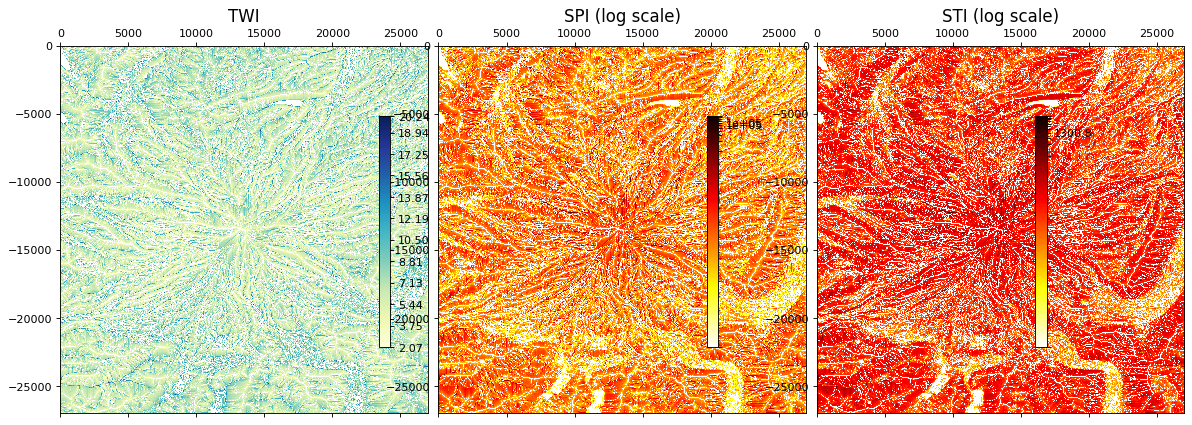

In [19]:
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
twi_show = np.where(twi == -9999.0, np.nan, twi).astype(np.float32)
spi_show = np.where((spi == -9999.0) | (spi <= 0), np.nan, spi).astype(np.float32)
sti_show = np.where((sti == -9999.0) | (sti <= 0), np.nan, sti).astype(np.float32)

Dataset.dataset_like(filled, twi_show).plot(
    band=0, ax=axes[0], cmap="YlGnBu", title="TWI", add_colorbar=True)
Dataset.dataset_like(filled, spi_show).plot(
    band=0, ax=axes[1], cmap="hot_r", color_scale="sym-lognorm",
    title="SPI (log scale)", add_colorbar=True)
Dataset.dataset_like(filled, sti_show).plot(
    band=0, ax=axes[2], cmap="hot_r", color_scale="sym-lognorm",
    title="STI (log scale)", add_colorbar=True)

fig.tight_layout()
plt.show()


## 11. Terrain attributes — focal-window stats + curvature

Topographic Position Index, deviation-from-mean elevation, focal SD, ruggedness, and the
five-variant curvature family.

In [20]:
tpi = dem.tpi(window=11).read_array()
dev = dem.deviation_from_mean(window=11).read_array()
sd = dem.elev_std(window=11).read_array()
rug = dem.ruggedness(window=3).read_array()

no_val = -9999.0
for name, arr in (("TPI", tpi), ("DevFromMean", dev), ("ElevStd", sd), ("Ruggedness", rug)):
    valid_a = arr[(arr != no_val) & np.isfinite(arr)]
    unit = "m" if name in ("TPI", "ElevStd", "Ruggedness") else ""
    print(f"{name:12s}: range=[{valid_a.min():>+8.2f}, {valid_a.max():>+8.2f}] {unit}")

print("\nCurvature family (each variant on the same DEM):")
for kind in ("plan", "profile", "total", "mean", "gaussian"):
    arr = dem.curvature(kind=kind).read_array()
    valid_a = arr[(arr != no_val) & np.isfinite(arr)]
    print(f"  {kind:9s}: range=[{valid_a.min():>+10.4f}, {valid_a.max():>+10.4f}]")

TPI         : range=[  -96.56,  +122.03] m
DevFromMean : range=[   -3.16,    +2.57] 
ElevStd     : range=[   +0.00,  +118.78] m
Ruggedness  : range=[   +0.00,  +417.25] m

Curvature family (each variant on the same DEM):
  plan     : range=[   -0.1190,    +0.1297]


  profile  : range=[   -0.1725,    +0.1122]
  total    : range=[   -0.3022,    +0.2011]
  mean     : range=[   -0.1511,    +0.1006]


  gaussian : range=[   -0.0045,    +0.0224]


## Visualise: TPI / ruggedness / curvature

C:\Users\main\AppData\Local\Temp\ipykernel_31632\1004748198.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


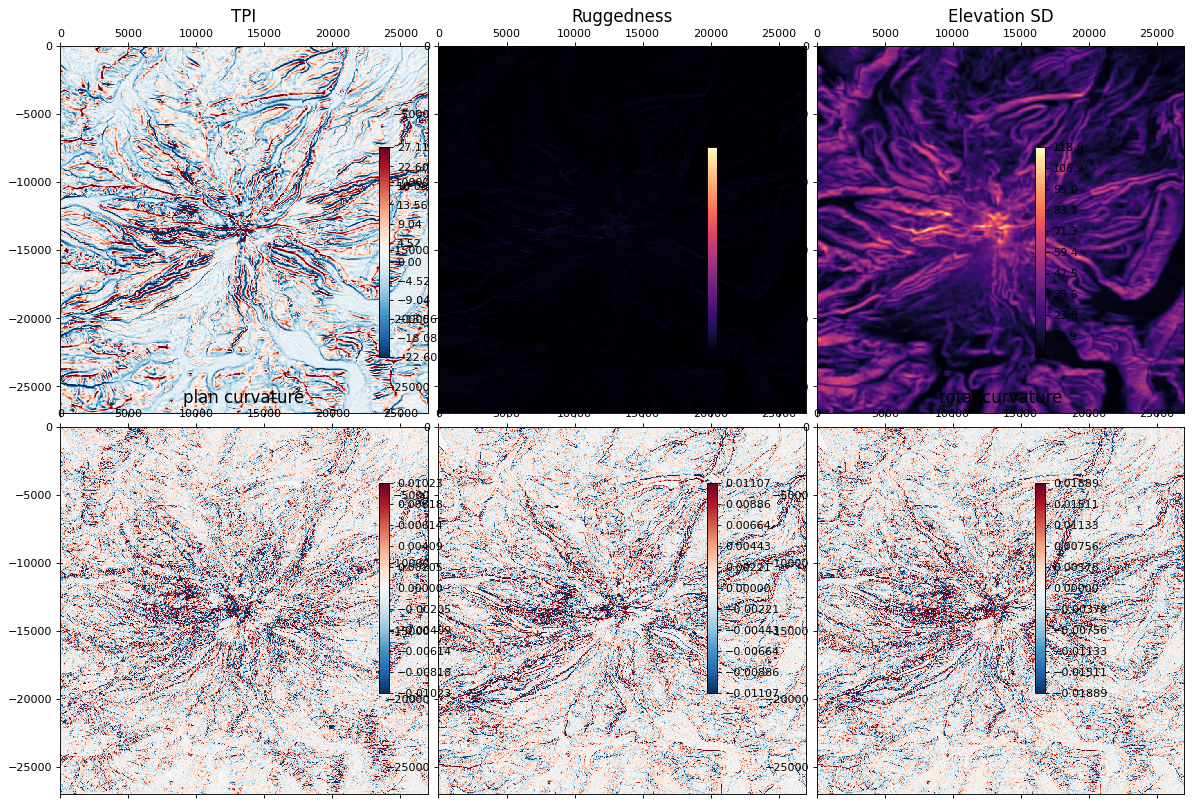

In [21]:
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
no_val = -9999.0

def _maskna(a):
    return np.where((a == no_val) | (~np.isfinite(a)), np.nan, a).astype(np.float32)

tpi_show = _maskna(tpi)
vlim = float(np.nanpercentile(np.abs(tpi_show), 95))
Dataset.dataset_like(dem, tpi_show).plot(
    band=0, ax=axes[0, 0], cmap="RdBu_r", vmin=-vlim, vmax=vlim,
    title="TPI", add_colorbar=True)

Dataset.dataset_like(dem, _maskna(rug)).plot(
    band=0, ax=axes[0, 1], cmap="magma", title="Ruggedness", add_colorbar=True)
Dataset.dataset_like(dem, _maskna(sd)).plot(
    band=0, ax=axes[0, 2], cmap="magma", title="Elevation SD", add_colorbar=True)

for ax, kind in zip(axes[1, :], ("plan", "profile", "total")):
    arr = _maskna(dem.curvature(kind=kind).read_array())
    vlim = float(np.nanpercentile(np.abs(arr), 95))
    Dataset.dataset_like(dem, arr).plot(
        band=0, ax=ax, cmap="RdBu_r", vmin=-vlim, vmax=vlim,
        title=kind + " curvature", add_colorbar=True)

fig.tight_layout()
plt.show()


## 12. Visibility — openness + sky-view factor

Yokoyama 2002 positive openness highlights ridges and summits; negative openness highlights
valley floors. Sky-view factor reports the visible-sky fraction per cell.

We use `search_radius=15` (~450 m at 30 m cells) to keep runtime reasonable on this 750×750
subset. Larger radii give smoother surfaces but cost O(N · radius).

In [22]:
openness_pos = dem.openness(search_radius=15, kind="positive").read_array()
openness_neg = dem.openness(search_radius=15, kind="negative").read_array()
svf = dem.sky_view_factor(search_radius=15).read_array()

for name, arr in (
    ("Positive openness (rad)", openness_pos),
    ("Negative openness (rad)", openness_neg),
    ("Sky-view factor      ", svf),
):
    valid_a = arr[(arr != -9999.0) & np.isfinite(arr)]
    print(f"{name}: range=[{valid_a.min():>6.4f}, {valid_a.max():>7.4f}]  "
          f"mean={valid_a.mean():>6.4f}")

Positive openness (rad): range=[0.7320,  1.5708]  mean=1.4409
Negative openness (rad): range=[0.5276,  1.5708]  mean=1.4400
Sky-view factor      : range=[0.2972,  1.0000]  mean=0.8730


## Visualise: openness + sky-view factor

C:\Users\main\AppData\Local\Temp\ipykernel_31632\1088303581.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


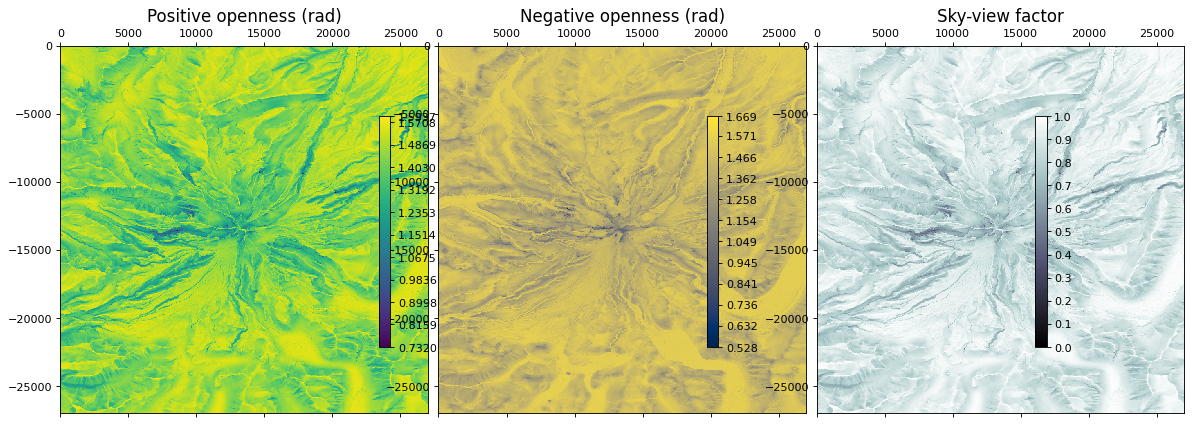

In [23]:
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pos_show = np.where(openness_pos == -9999.0, np.nan, openness_pos).astype(np.float32)
neg_show = np.where(openness_neg == -9999.0, np.nan, openness_neg).astype(np.float32)
svf_show = np.where(svf == -9999.0, np.nan, svf).astype(np.float32)

Dataset.dataset_like(dem, pos_show).plot(
    band=0, ax=axes[0], cmap="viridis",
    title="Positive openness (rad)", add_colorbar=True)
Dataset.dataset_like(dem, neg_show).plot(
    band=0, ax=axes[1], cmap="cividis",
    title="Negative openness (rad)", add_colorbar=True)
Dataset.dataset_like(dem, svf_show).plot(
    band=0, ax=axes[2], cmap="bone", vmin=0, vmax=1,
    title="Sky-view factor", add_colorbar=True)

fig.tight_layout()
plt.show()


## 13. Stochastic depression analysis

SRTM 30 m has ~7 m stated vertical accuracy. Run Monte-Carlo depression detection at σ = 5 m
with 20 realisations to flag which depressions are robust to noise vs likely artefacts.

In [24]:
stoch = dem.stochastic_depressions(sigma=5.0, n_runs=20, seed=2026).read_array()

# Build a baseline depression mask from the filled DEM (cells lifted by the fill).
elev = dem.values
filled_arr = filled.values
baseline_depr = (filled_arr - elev) > 0.1
n_baseline = int(baseline_depr.sum())

robust = (stoch >= 0.8) & baseline_depr
fragile = (stoch < 0.2) & baseline_depr

print(f"Deterministic depression cells: {n_baseline:>6d}")
print(f"Robust (P >= 0.80):            {int(robust.sum()):>6d}")
print(f"Fragile (P < 0.20, likely noise): {int(fragile.sum()):>6d}")

Deterministic depression cells:   1760
Robust (P >= 0.80):               174
Fragile (P < 0.20, likely noise):     18


## Visualise: stochastic depression probability

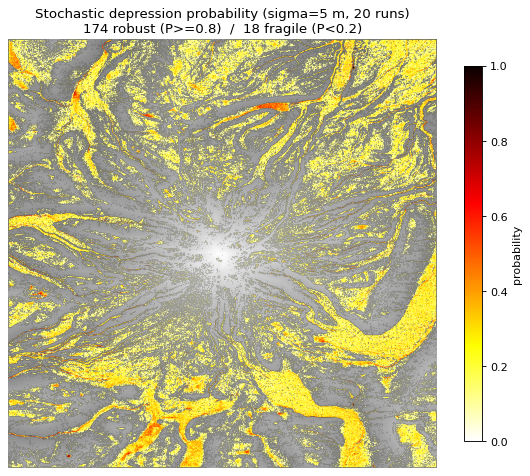

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
prob = np.where(stoch == -1.0, np.nan, stoch)
ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
prob_overlay = np.where(prob > 0, prob, np.nan)
im = ax.imshow(prob_overlay, cmap="hot_r", vmin=0, vmax=1, origin="upper")
ax.set_title("Stochastic depression probability (sigma=5 m, 20 runs)\n"
             + str(int(robust.sum())) + " robust (P>=0.8)  /  "
             + str(int(fragile.sum())) + " fragile (P<0.2)")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.7, label="probability")
fig.tight_layout()
plt.show()


## Summary

On a real 30 m SRTM tile from AWS Open Data, cropped to a 0.25° square around Mount Hood:

| Surface | Result |
|---------|--------|
| Hydro pipeline | full fill → flow_direction → accumulate → streams in one call |
| Stream orders | Strahler / Hack / Topological |
| Vectorisation | LineStrings with length, drop, slope, sinuosity per link |
| Main stem | binary mask along the longest source-to-outlet trace |
| Watershed basins | terminal-outlet partition + per-basin stats |
| Longest flow path | column on the basin-statistics table |
| Isobasins | equal-area sub-basin partition at ~1 km² target |
| HAND — D8 + Euclidean | flood-proxy elevation above nearest drainage |
| TWI / SPI / STI | classic catchment-scale indices |
| TPI / DevFromMean / ElevStd / Ruggedness | focal-window terrain stats |
| Curvature family | 5 Zevenbergen-Thorne variants |
| Openness positive / negative | Yokoyama 2002 visibility |
| Sky-view factor | Zakšek et al. 2011 visible-sky fraction |
| Stochastic depressions | Monte-Carlo robustness across DEM noise |

Every result above was computed end-to-end from a single 12.4 MB SRTM tile downloaded over HTTP
with no authentication — fully reproducible from a clean checkout.